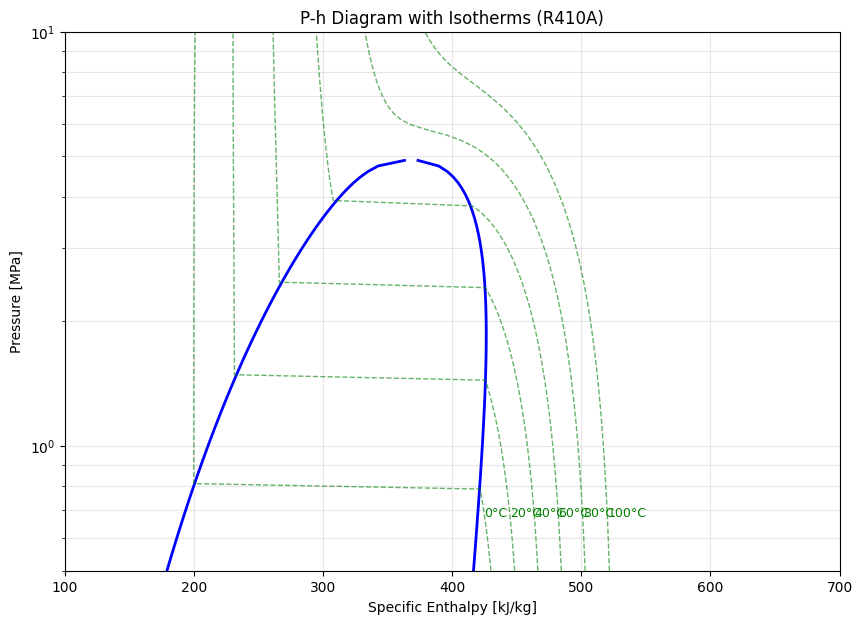

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

def plot_ph_diagram(fluid_name, color):
    # 臨界点の取得
    T_crit = CP.PropsSI('Tcrit', fluid_name)
    P_crit = CP.PropsSI('Pcrit', fluid_name)
    T_min = CP.PropsSI('Tmin', fluid_name)
    
    # --- 1. 飽和線の描画 ---
    T_range = np.linspace(T_min + 1.0, T_crit - 0.1, 100)
    h_l = [CP.PropsSI('H', 'T', T, 'Q', 0, fluid_name) / 1000 for T in T_range]
    p_l = [CP.PropsSI('P', 'T', T, 'Q', 0, fluid_name) / 1e6 for T in T_range]
    h_v = [CP.PropsSI('H', 'T', T, 'Q', 1, fluid_name) / 1000 for T in T_range]
    p_v = [CP.PropsSI('P', 'T', T, 'Q', 1, fluid_name) / 1e6 for T in T_range]
    
    plt.plot(h_l, p_l, color=color, lw=2, label=f'{fluid_name} Sat. Curve')
    plt.plot(h_v, p_v, color=color, lw=2)

    # --- 2. 等温線の追加 ---
    # 表示したい温度（Celsius）を設定
    T_celsius = [0, 20, 40, 60, 80, 100]
    # 圧力の描画範囲（y軸の範囲に合わせる）
    p_range = np.geomspace(0.5e6, 10e6, 100) # 0.5MPaから10MPaまで

    for Tc in T_celsius:
        T_kelvin = Tc + 273.15
        h_isotherm = []
        p_isotherm = []
        
        for p in p_range:
            try:
                # 指定した温度・圧力でのエンタルピーを計算
                h = CP.PropsSI('H', 'T', T_kelvin, 'P', p, fluid_name) / 1000
                h_isotherm.append(h)
                p_isotherm.append(p / 1e6)
            except:
                continue # 物性値が計算できない範囲（超臨界など）はスキップ
        
        plt.plot(h_isotherm, p_isotherm, 'g--', lw=1, alpha=0.6)
        # 線の上に温度をテキスト表示（適当な位置：P=1.0MPa付近）
        if h_isotherm:
            plt.text(h_isotherm[10], p_isotherm[10], f'{Tc}°C', fontsize=9, color='green')

# グラフ設定
plt.figure(figsize=(10, 7))

# R410A をプロット
plot_ph_diagram('R410A', 'blue')

# 仕上げ
plt.yscale('log')
plt.xlabel('Specific Enthalpy [kJ/kg]')
plt.ylabel('Pressure [MPa]')
plt.title('P-h Diagram with Isotherms (R410A)')
plt.grid(True, which="both", ls="-", alpha=0.3)

# 軸の範囲調整
plt.xlim(100, 700)
plt.ylim(0.5, 10)

plt.show()

/var/folders/7b/1jnhctp97vxgzcrx3cgf_wyw0000gn/T/ipykernel_51052/3842461084.py:84: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot([h_cond_airout, h_inlet], [P_evap_MPa, P_evap_MPa], 'b-', lw=2, ls=':')


NameError: name 'P_evap' is not defined

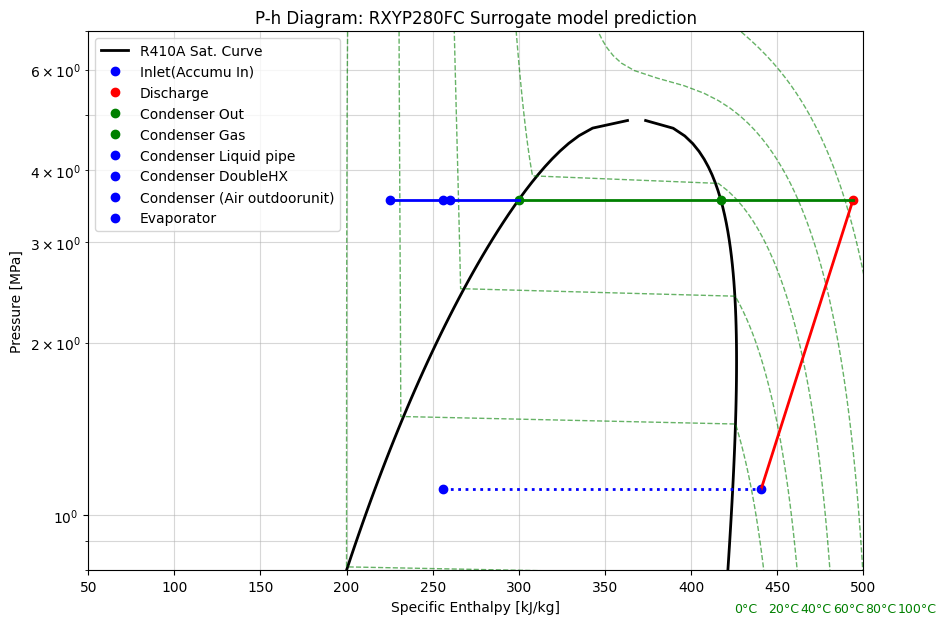

In [ ]:
T_evap_C = 10.8
T_cond_C = 56.5
T_dis_C = 103.8
T_cond_liquidpipe = 37.4
T_accum_in_C = 25.2
T_doubleHX_C = 16.4

# 室外機の外気温
T_airout_C = 35

T_cond_liquid_C = 37.4

C_K_convert = 273.15

T_evap = T_evap_C + C_K_convert
T_cond = T_cond_C +  C_K_convert

T_cond_liquid = T_cond_liquid_C + C_K_convert

T_dis = T_dis_C +  C_K_convert
T_accumu_in = T_accum_in_C +  C_K_convert
T_doubleHX = T_doubleHX_C +  C_K_convert

T_airout = T_airout_C + C_K_convert

fluid_name = "R410A"

# グラフ設定
plt.figure(figsize=(10, 7))

# R410A をプロット
plot_ph_diagram('R410A', 'black')

# 1. Calculate Pressures (Pa)
P_evap_Pa = CP.PropsSI('P', 'T', T_evap, 'Q', 1, fluid_name) 
P_cond_Pa = CP.PropsSI('P', 'T', T_cond, 'Q', 0, fluid_name)
T_cond_q0 = CP.PropsSI('T', 'T', T_cond, 'Q', 0, fluid_name)

# 2. Calculate Enthalpies (kJ/kg)
# Point 1: Compressor Inlet (Assuming saturated vapor for simplicity, or use T_accumu_in)
h_inlet = CP.PropsSI('H', 'P', P_evap_Pa, 'T', T_accumu_in, fluid_name) / 1000

# Point 2: Compressor Discharge (Using measured T_dis)
h_dis = CP.PropsSI('H', 'P', P_cond_Pa, 'T', T_dis, fluid_name) / 1000

h_cond_gas = CP.PropsSI('H', 'P', P_cond_Pa, 'Q', 1 , fluid_name) / 1000

# Point 3: Condenser Exit (Saturated liquid at T_cond)
h_cond_out = CP.PropsSI('H', 'P', P_cond_Pa, 'Q', 0, fluid_name) / 1000
h_cond_liquid = CP.PropsSI('H', 'P', P_cond_Pa, 'T', T_cond_liquid, fluid_name) / 1000
h_cond_doubleHX = CP.PropsSI('H', 'P', P_cond_Pa, 'T', T_doubleHX, fluid_name) / 1000

h_cond_airout = CP.PropsSI('H', 'P', P_cond_Pa, 'T', T_airout, fluid_name) / 1000

# Convert to MPa for plotting
P_evap_MPa = P_evap_Pa / 1e6
P_cond_MPa = P_cond_Pa / 1e6


# Plot Points
plt.plot(h_inlet, P_evap_MPa, 'bo', label="Inlet(Accumu In)")
plt.plot(h_dis, P_cond_MPa, 'ro', label="Discharge")
plt.plot(h_cond_out, P_cond_MPa, 'go', label="Condenser Out")
plt.plot(h_cond_gas, P_cond_MPa, 'go', label="Condenser Gas")
plt.plot(h_cond_liquid, P_cond_MPa, 'bo', label="Condenser Liquid pipe")
plt.plot(h_cond_doubleHX, P_cond_MPa, 'bo', label="Condenser DoubleHX")

plt.plot(h_cond_airout, P_cond_MPa, 'bo', label="Condenser (Air outdoorunit)")

plt.plot(h_cond_airout, P_evap_MPa, 'bo', label="Evaporator")

# Plot Compression Line (Point 1 to Point 2)
plt.plot([h_inlet, h_dis], [P_evap_MPa, P_cond_MPa], 'r-', lw=2)

# Plot Condensation Line (Point 2 to Point 3)
plt.plot([h_dis, h_cond_out], [P_cond_MPa, P_cond_MPa], 'g-', lw=2)

# Plot Condensation Line (Airout, LiquidPipe)
plt.plot([h_cond_out, h_cond_airout], [P_cond_MPa, P_cond_MPa], 'b-', lw=2)
plt.plot([h_cond_airout, h_cond_liquid], [P_cond_MPa, P_cond_MPa], 'b-', lw=2)
plt.plot([h_cond_airout,h_cond_doubleHX], [P_cond_MPa, P_cond_MPa], 'b-', lw=2)

# Plot Evapolator line
plt.plot([h_cond_airout, h_inlet], [P_evap_MPa, P_evap_MPa], 'b-', lw=2, ls=':')



# 仕上げ
# 軸の範囲調整（見やすくするため）
plt.xlim(50, 500)
plt.ylim(0.8, 7)

plt.yscale('log') # 圧力は対数軸が一般的
plt.xlabel('Specific Enthalpy [kJ/kg]')
plt.ylabel('Pressure [MPa]')
plt.title('P-h Diagram: RXYP280FC Surrogate model prediction')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()

print(P_evap)
print(P_cond)
print(h_dis)
print(T_cond_q0 - C_K_convert)

In [4]:
h_cond_q0 = CP.PropsSI('H', 'P', P_cond * 1e6, 'Q', 0 , fluid_name) / 1000
print(h_cond_q0)

NameError: name 'P_cond' is not defined

In [5]:
import sys
print(sys.executable)

/Users/hajime.ikeda/work/coolprop-vrvdata-analysis/.venv/bin/python


In [6]:
# 1. 飽和液の比エンタルピー (Quality = 0)
# p_bubble の状態に相当します
h_l = CP.PropsSI('H', 'T', temp_k, 'Q', 0, fluid)

# 2. 飽和蒸気の比エンタルピー (Quality = 1)
# p_dew の状態に相当します
h_v = CP.PropsSI('H', 'T', temp_k, 'Q', 1, fluid)

# 蒸発潜熱 (Latent Heat) の計算
h_fg = h_v - h_l

print(f"--- {fluid} (温度: {temp_c} ℃) の比エンタルピー ---")
print(f"飽和液比エンタルピー (h_l): {h_l / 1000:.2f} kJ/kg")
print(f"飽和蒸気比エンタルピー (h_v): {h_v / 1000:.2f} kJ/kg")
print(f"蒸発潜熱 (h_fg): {h_fg / 1000:.2f} kJ/kg")

NameError: name 'temp_k' is not defined

## Ph線図上に冷凍サイクルの動作点を描く作業を関数にしておく

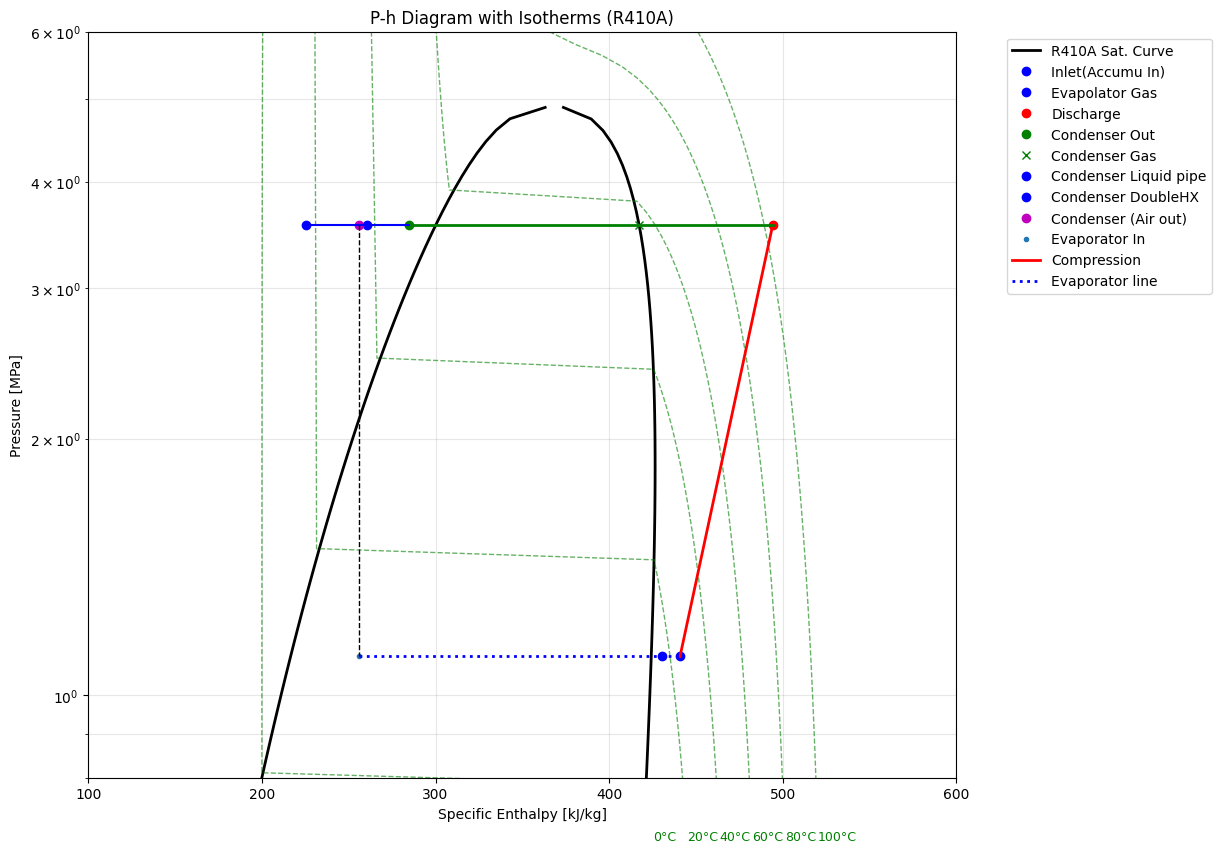

In [7]:
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

def plot_refrigeration_cycle(T_evap_C, T_cond_C, T_dis_C, T_accum_in_C, 
                             T_cond_out_C, T_airout_C, T_liquidpipe_C, T_doubleHX_C,T_indoor_gas_C,
                             fluid_name="R410A"):
    """
    実測データに基づき、冷凍サイクルの詳細な各動作点をpH線図上にプロットする。

    Args:
        T_evap_C (float): 蒸発温度 [°C] (低圧側飽和圧力算出用)
        T_cond_C (float): 凝縮温度 [°C] (高圧側飽和圧力算出用)
        T_dis_C (float): 圧縮機吐出温度 [°C]
        T_accum_in_C (float): アキュムレータ入口温度 [°C] (吸入点)
        T_cond_out_C (float): 凝縮器出口温度 [°C]
        T_airout_C (float): 室外機外気温 [°C] (比較参照点)
        T_liquidpipe_C (float): 液管温度 [°C]
        T_doubleHX_C (float): 二重管熱交出口温度 [°C] (過冷却ガス間温度)
        T_indoor_gas_C (室内機熱交換器のガス管温度)
        fluid_name (str): 冷媒名 (デフォルト "R410A")

    Returns:
        dict: 各計算ポイントのエンタルピ [kJ/kg] と圧力 [MPa]
    """
    C_K_convert = 273.15
    
    # --- 1. 圧力の計算 (Pa -> MPa) ---
    P_evap_Pa = CP.PropsSI('P', 'T', T_evap_C + C_K_convert, 'Q', 1, fluid_name)
    P_cond_Pa = CP.PropsSI('P', 'T', T_cond_C + C_K_convert, 'Q', 0, fluid_name)
    
    P_evap_MPa = P_evap_Pa / 1e6
    P_cond_MPa = P_cond_Pa / 1e6

    # --- 2. 各点のエンタルピ計算 (J/kg -> kJ/kg) ---
    def get_h(T, P):
        return CP.PropsSI('H', 'T', T + C_K_convert, 'P', P, fluid_name) / 1000.0

    h_inlet = get_h(T_accum_in_C, P_evap_Pa)       # Inlet (Accumu In)
    h_indoor_gas = get_h(T_indoor_gas_C, P_evap_Pa)  
    h_dis = get_h(T_dis_C, P_cond_Pa)             # Discharge
    h_cond_out = get_h(T_cond_out_C, P_cond_Pa)   # Condenser Out
    h_cond_airout = get_h(T_airout_C, P_cond_Pa)  # Condenser (Air outdoorunit)
    h_cond_liquid = get_h(T_liquidpipe_C, P_cond_Pa) # Condenser Liquid pipe
    h_cond_doubleHX = get_h(T_doubleHX_C, P_cond_Pa) # Condenser DoubleHX
    
    # 飽和線の交点（補助用）
    h_cond_gas = CP.PropsSI('H', 'P', P_cond_Pa, 'Q', 1, fluid_name) / 1000.0
    h_cond_liquid_sat = CP.PropsSI('H', 'P', P_cond_Pa, 'Q', 0, fluid_name) / 1000.0

    # --- 3. プロット (Points) ---
    pts = [
        (h_inlet, P_evap_MPa, 'bo', "Inlet(Accumu In)"),
        (h_indoor_gas, P_evap_MPa, 'bo', "Evapolator Gas"),
        (h_dis, P_cond_MPa, 'ro', "Discharge"),
        (h_cond_out, P_cond_MPa, 'go', "Condenser Out"),
        (h_cond_gas, P_cond_MPa, 'gx', "Condenser Gas"),
        (h_cond_liquid, P_cond_MPa, 'bo', "Condenser Liquid pipe"),
        (h_cond_doubleHX, P_cond_MPa, 'bo', "Condenser DoubleHX"),
        (h_cond_airout, P_cond_MPa, 'mo', "Condenser (Air out)"),
        (h_cond_airout, P_evap_MPa, '.', "Evaporator In")
    ]
    
    for h, p, style, lbl in pts:
        plt.plot(h, p, style, label=lbl)

    # --- 4. プロット (Lines) ---
    # 圧縮工程
    plt.plot([h_inlet, h_dis], [P_evap_MPa, P_cond_MPa], 'r-', lw=2, label="Compression")
    
    # 凝縮工程 (吐出 -> 凝縮器出口)
    plt.plot([h_dis, h_cond_out], [P_cond_MPa, P_cond_MPa], 'g-', lw=2)
    
    # サブクール・液管・二重管ライン
    plt.plot([h_cond_out, h_cond_airout], [P_cond_MPa, P_cond_MPa], 'b-', lw=1.5)
    plt.plot([h_cond_airout, h_cond_liquid], [P_cond_MPa, P_cond_MPa], 'b-', lw=1.5)
    plt.plot([h_cond_airout, h_cond_doubleHX], [P_cond_MPa, P_cond_MPa], 'b-', lw=1.5)
    
    # 蒸発器ライン (膨張弁通過後の等エンタルピ想定)
    # ここでは h_cond_airout を基準点として蒸発器入口へつなぐ
    plt.plot([h_cond_airout, h_inlet], [P_evap_MPa, P_evap_MPa], 'b:', lw=2, label="Evaporator line")

    # 膨張弁 (等エンタルピ)
    plt.plot([h_cond_airout, h_cond_airout], [P_cond_MPa, P_evap_MPa], 'k--', lw=1)

    return locals() # 計算した全変数を辞書で返す

# --- 実行コード ---
plt.figure(figsize=(12, 8))

# R410A をプロット
plot_ph_diagram('R410A', 'black')

# 仮の plot_ph_diagram 実行後に呼び出し
# plot_ph_diagram('R410A', 'black')

plot_refrigeration_cycle(
    T_evap_C = 10.8,
    T_cond_C = 56.5,
    T_dis_C = 103.8,
    T_accum_in_C = 25.2,
    T_cond_out_C = 50.0,      # 仮設定（凝縮器出口）
    T_airout_C = 35.0,        # 外気温
    T_liquidpipe_C = 37.4,    # 液管温度
    T_doubleHX_C = 16.4,      # 二重管
    T_indoor_gas_C = 16,
    fluid_name = "R410A"
)

plt.yscale('log')
plt.grid(True, which='both', ls='-', alpha=0.2)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# 仕上げ
plt.yscale('log')
plt.xlabel('Specific Enthalpy [kJ/kg]')
plt.ylabel('Pressure [MPa]')
plt.title('P-h Diagram with Isotherms (R410A)')
plt.grid(True, which="both", ls="-", alpha=0.3)

# 軸の範囲調整
plt.xlim(100, 600)
plt.ylim(0.8, 6)

plt.show()


In [ ]:
def plot_refrigeration_cycle_modify(current_now,  # data frame
                                    fluid_name="R410A"):
    """
    実測データに基づき、冷凍サイクルの詳細な各動作点をpH線図上にプロットする。

    Args:
        T_evap_C (float): 蒸発温度 [°C] (低圧側飽和圧力算出用)
        T_cond_C (float): 凝縮温度 [°C] (高圧側飽和圧力算出用)
        T_dis_C (float): 圧縮機吐出温度 [°C]
        T_accum_in_C (float): アキュムレータ入口温度 [°C] (吸入点)
        T_cond_out_C (float): 凝縮器出口温度 [°C]
        T_airout_C (float): 室外機外気温 [°C] (比較参照点)
        T_liquidpipe_C (float): 液管温度 [°C]
        T_doubleHX_C (float): 二重管熱交出口温度 [°C] (過冷却ガス間温度)
        T_indoor_gas_C (室内機熱交換器のガス管温度)
        fluid_name (str): 冷媒名 (デフォルト "R410A")

    Returns:
        dict: 各計算ポイントのエンタルピ [kJ/kg] と圧力 [MPa]
    """
    plot_ph_background(fluid)

    try:
        # スライダーで選ばれた時刻のデータを使用して計算
        T_evap_C = current_row['teg']
        T_cond_C = current_row['tcg']
        T_dis_C = current_row['compressor_1_dischargetemp']
        T_accum_in_C = current_row['ts'] #アキュムレータ入口温度
        T_cond_out_C = current_row['t_liquid']      # 凝縮器出口
        T_airout_C = 35.0        # 外気温（仮設定）
        T_liquidpipe_C = current_row['t_liquid']  # 液管温度(データがないので't_liquid'を入れる)
        T_doubleHX_C = current_row['tsh']      # 二重管
        T_indoor_gas_C = current_row['indoor_gas']      # 室内機熱交換器のガス（気相）
        fluid_name = "R410A"

        #st.write(T_liquidpipe_C,T_doubleHX_C)
        
        # --- 圧力・エンタルピ計算 ---
        P_evap_Pa = CP.PropsSI('P', 'T', T_evap_C + 273.15, 'Q', 1, fluid)
        P_cond_Pa = CP.PropsSI('P', 'T', T_cond_C + 273.15, 'Q', 0, fluid)

        C_K_convert = 273.15
        
        P_evap_MPa = P_evap_Pa / 1e6
        P_cond_MPa = P_cond_Pa / 1e6

        # R410Aなどの非共沸冷媒は、Q=0.5などでCoolPropに入力するとエラーになる
        # P_doubleHX_Pa = CP.PropsSI('P','T', T_doubleHX_C + 273.15,'Q',0.5,fluid)
        # P_doubleHX_Pa = CP.PropsSI('P','T', T_doubleHX_C + 273.15,'Q',1.0,fluid)
        # P_doubleHX_MPa = P_doubleHX_Pa / 1e6


        def get_h(T_C, P_Pa, fluid):
            T_K = T_C + 273.15
    
            try:
                # 指定したT, Pで直接計算を試みる（単相域：過冷却液 or 過熱蒸気）
                return CP.PropsSI('H', 'T', T_K, 'P', P_Pa, fluid) / 1000.0
            
            except ValueError:
                # T, Pが飽和域にある場合、あるいは境界上の場合はエラーになるため
                # 飽和蒸気の値を返すなどの例外処理が必要
                print("Warning: State is in the saturation region or input is invalid.")
                return None

        h_inlet = get_h(T_accum_in_C, P_evap_Pa,fluid_name)       # Inlet (Accumu In)
        h_dis = get_h(T_dis_C, P_cond_Pa,fluid_name)             # Discharge
        h_cond_out = get_h(T_cond_out_C, P_cond_Pa,fluid_name)   # Condenser Out
        h_airout = get_h(T_airout_C, P_cond_Pa,fluid_name)  # Condenser (Air outdoorunit) 外気温度
        h_cond_liquid = get_h(T_liquidpipe_C, P_cond_Pa,fluid_name) # Condenser Liquid pipe
        
        h_doubleHX_in = h_cond_out  # 二重管入口　凝縮器出口のエンタルピーは同じ
        h_doubleHX_out = get_h(T_doubleHX_C,P_evap_Pa,fluid_name) # DoubleHX out 　二重管出口のエンタルピーは過冷却管温度から算出する
        
        h_evap_indoor_gas = get_h(T_indoor_gas_C, P_evap_Pa,fluid_name) # 室内ガスガス管
        # 飽和線の交点（補助用）
        h_cond_gas = CP.PropsSI('H', 'P', P_cond_Pa, 'Q', 1, fluid_name) / 1000.0
        h_cond_liquid_sat = CP.PropsSI('H', 'P', P_cond_Pa, 'Q', 0, fluid_name) / 1000.0

       
        # --- 3. プロット (Points) ---
        pts = [
            (h_inlet, P_evap_MPa, 'bs', "Inlet(Accumu In)"),
            (h_evap_indoor_gas, P_evap_MPa, 'bo', "Evaporator Gas"),
            (h_dis, P_cond_MPa, 'rs', "Discharge"),
            (h_cond_out, P_cond_MPa, 'gs', "Condenser Out"),
            (h_cond_gas, P_cond_MPa, 'gx', "Condenser Gas"),
            (h_cond_liquid, P_cond_MPa, 'bs', "Condenser Liquid pipe"),
            (h_doubleHX_in, P_evap_MPa, 'go', "DoubleHX in (EVT out)"),
            (h_doubleHX_out, P_evap_MPa, 'go', "DoubleHX out "),
            (h_airout, P_cond_MPa, 'm.', "Outdoor Unit (Air out)"), # 外気温度 
            (h_cond_out, P_evap_MPa, '.', "Evaporator In")
        ]

        #st.write('DoubleHX out Enthalpy=',h_doubleHX_out,'Enthalpy (Evap gas)=',h_evap_indoor_gas)
        #st.write('SC: T_cg - T_liquidpipe_cg',T_cond_C - T_liquidpipe_C)
        #st.write('SH (evap): T_indoor_gas - T_eg',T_indoor_gas_C - T_evap_C)
        #st.write('SH (doubleHX):T_doubleHX - T_eg',T_doubleHX_C - T_evap_C)

        for h, p, style, lbl in pts:
            plt.plot(h, p, style, label=lbl)

        # --- 4. プロット (Lines) ---
        # 圧縮工程
        plt.plot([h_inlet, h_dis], [P_evap_MPa, P_cond_MPa], 'r-', lw=2, label="Compression")
    
        # 凝縮工程 (吐出 -> 凝縮器出口)
        plt.plot([h_dis, h_cond_out], [P_cond_MPa, P_cond_MPa], 'g-', lw=2)
    
        # サブクール・液管・二重管ライン
        #plt.plot([h_cond_out, h_cond_airout], [P_cond_MPa, P_cond_MPa], 'b-', lw=1.5)
        #plt.plot([h_cond_airout, h_cond_liquid], [P_cond_MPa, P_cond_MPa], 'b-', lw=1.5)
        #plt.plot([h_cond_airout, h_doubleHX_in], [P_cond_MPa, P_cond_MPa], 'b-', lw=1.5)
    
        # 蒸発器ライン (膨張弁通過後の等エンタルピ想定)
        # ここでは h_cond_out を基準点として蒸発器入口へつなぐ
        plt.plot([h_cond_out, h_inlet], [P_evap_MPa, P_evap_MPa], 'b:', lw=2, label="Evaporator line")

        # 膨張弁 (等エンタルピ)
        plt.plot([h_cond_out, h_cond_out], [P_cond_MPa, P_evap_MPa], 'k--', lw=1)

        # 二重管熱交換器のライン
        plt.plot([h_cond_out, h_doubleHX_out], [P_evap_MPa, P_evap_MPa], 'b--', lw=1)
        
        plt.set_yscale('log')
        plt.set_xlim(100, 600)
        plt.set_ylim(0.5, 5.0) # 圧力範囲はデータに合わせて調整
        plt.set_xlabel('Enthalpy [kJ/kg]')
        plt.set_ylabel('Pressure [MPa]')
        plt.grid(True, which="both", alpha=0.3)
        #ax.legend()

        # ax.legend(loc='best', borderaxespad=0, fontsize='small')
        plt.legend(loc='upper left', fontsize='small') 

    except Exception as e:
        print(f"この時刻の物性計算ができませんでした: {e}")

## 市場データが符号判定に合ってるか確認する

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
path_to_file = '../data/vrv-transfer-learning/transfer_learning_RQYP224FC_20260225.parquet'
df = pd.read_parquet(path_to_file)
pd.set_option('display.max_info_columns', 20)
df.info()

# 1. シンプルにリスト形式で全カラムをプリントする（これが一番確実です）
print(f"Total columns: {len(df.columns)}")
for i, col in enumerate(df.columns):
    print(f"{i:2}: {col}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35363 entries, 0 to 35362
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   timestamp                       35363 non-null  object 
 1   tcg                             35363 non-null  float64
 2   t_liquid                        35363 non-null  float64
 3   rpm                             35363 non-null  float64
 4   teg                             35363 non-null  float64
 5   ts                              35363 non-null  float64
 6   tsh                             35363 non-null  float64
 7   compressor_1_dischargetemp      35363 non-null  float64
 8   refrigerantpipe_1_highpressure  35363 non-null  float64
 9   compressor_coolingfin_temp      35363 non-null  float64
 10  compressor_surface_temp         35363 non-null  float64
 11  outdoor_deicer_temp             35363 non-null  float64
 12  stopvalve_liquid_temp           

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

path_to_file = '../data/vrv-transfer-learning/transfer_learning_RQYP224FC_20260225.parquet'
df = pd.read_parquet(path_to_file)

# 1. timestampをdatetime型に変換
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 2. timestampをインデックスに設定（時系列操作がしやすくなります）
df = df.set_index('timestamp').sort_index()

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. データの抽出
df_slice = df.loc['2023-08-20 08:00':'2023-08-21 12:00']

# 2. 上下2段のサブプロットを作成（下段だけ2軸設定）
fig = make_subplots(
    rows=2, cols=1, 
    shared_xaxes=True, 
    vertical_spacing=0.1,
    subplot_titles=("Output: Temperatures (Result)", "Input: Compressor RPM & EV Pulse (Control)"),
    specs=[[{"secondary_y": False}], [{"secondary_y": True}]]
)

# --- 上段: 温度（結果） ---
temp_cols = ['teg','tcg', 't_liquid', 'compressor_1_dischargetemp']
for col in temp_cols:
    fig.add_trace(go.Scatter(x=df_slice.index, y=df_slice[col], name=col), row=1, col=1)

# --- 下段: 制御入力 ---
# 圧縮機回転数 (左軸)
fig.add_trace(
    go.Scatter(x=df_slice.index, y=df_slice['rpm'], name='RPM', line=dict(color='black')),
    row=2, col=1, secondary_y=False
)
# 室内機EVパルス (右軸)
fig.add_trace(
    go.Scatter(x=df_slice.index, y=df_slice['indoor_ev_pulse'], name='EV Pulse', line=dict(color='red', dash='dot')),
    row=2, col=1, secondary_y=True
)

# 3. レイアウト設定
fig.update_layout(
    height=800,
    width=None,
    title_text="Control Input vs System Response Analysis",
    hovermode='x unified',
    template='plotly_white',
    showlegend=True
)

# 軸ラベルの設定
fig.update_yaxes(title_text="Temp [℃]", row=1, col=1)
fig.update_yaxes(title_text="Speed [rpm]", row=2, col=1, secondary_y=False)
fig.update_yaxes(title_text="Pulse [step]", row=2, col=1, secondary_y=True)

fig.show()

fig.write_html(
    "../data/vrv-transfer-learning/figures/vrv_analysis_RQYP224FC.html",
    include_plotlyjs='cdn', # ライブラリをネット経由で読み込む（ファイルが軽くなる）
    full_html=True          # 単体のHTMLファイルとして完結させる
)


2023-08-21 06:25 64.0
tcg                                40.136719
t_liquid                           31.000000
rpm                               117.000000
teg                                 4.890625
ts                                 14.296875
tsh                                 5.000000
compressor_1_dischargetemp         64.000000
refrigerantpipe_1_highpressure      2.324728
compressor_coolingfin_temp         46.000000
compressor_surface_temp            60.000000
outdoor_deicer_temp                39.000000
stopvalve_liquid_temp              13.000000
subcool_mov_flowratio              43.000000
indoor_liquid                       7.703125
indoor_gas                         12.046875
indoor_ev_pulse                   520.000000
Name: 2023-08-21 06:25:00, dtype: float64


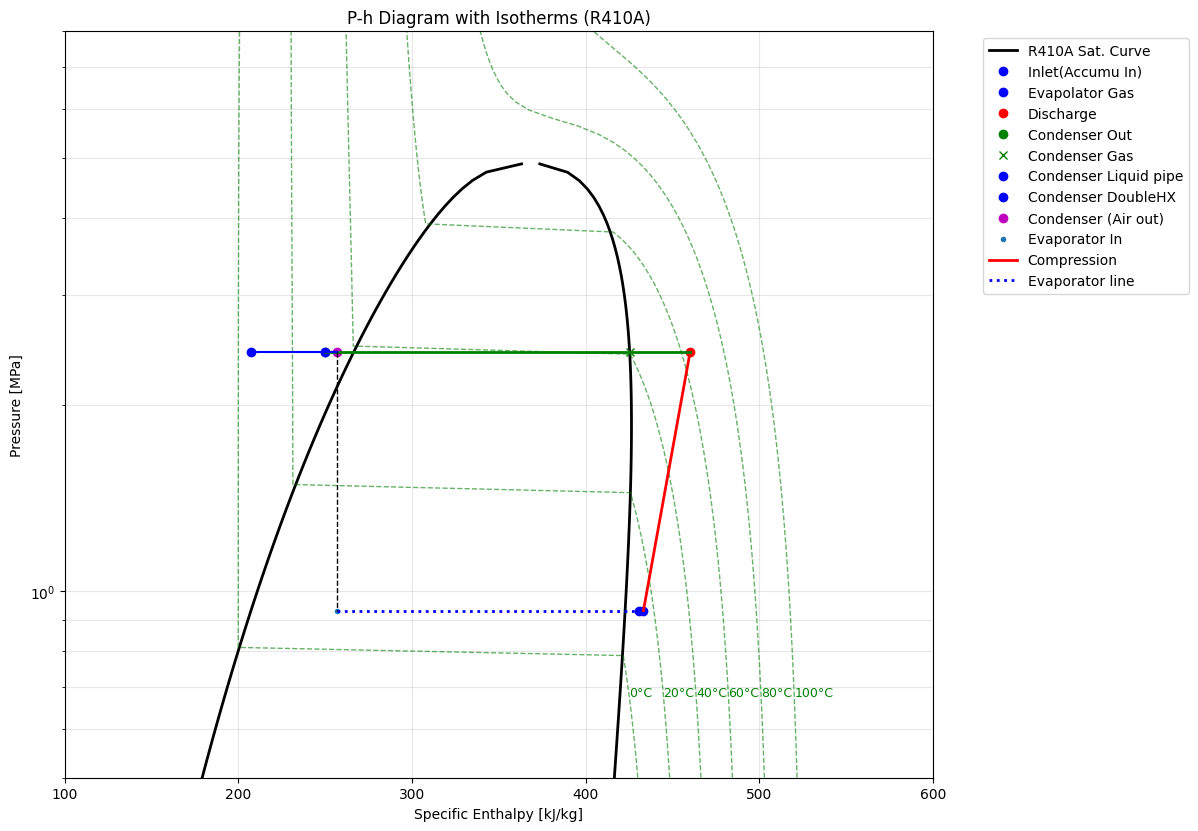

In [10]:

# --- 実行コード ---
plt.figure(figsize=(12, 8))

# R410A をプロット
plot_ph_diagram('R410A', 'black')


time_snapshot = '2023-08-21 06:25'
plot_refrigeration_cycle(
    T_evap_C = df.loc[time_snapshot]['teg'],
    T_cond_C = df.loc[time_snapshot]['tcg'],
    T_dis_C = df.loc[time_snapshot]['compressor_1_dischargetemp'],
    T_accum_in_C = df.loc[time_snapshot]['ts'], #アキュムレータ入口温度
    T_cond_out_C = df.loc[time_snapshot]['t_liquid'],      # 凝縮器出口
    T_airout_C = 35.0,        # 外気温（仮設定）
    T_liquidpipe_C = df.loc[time_snapshot]['t_liquid'], # 液管温度(データがないので't_liquid'を入れる)
    T_doubleHX_C = df.loc[time_snapshot]['tsh'],      # 二重管
    T_indoor_gas_C = df.loc[time_snapshot]['indoor_gas'],
    fluid_name = "R410A"
)

print(time_snapshot,df.loc[time_snapshot]['compressor_1_dischargetemp'])
print(df.loc[time_snapshot])

plt.yscale('log')
plt.grid(True, which='both', ls='-', alpha=0.2)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# 仕上げ
plt.yscale('log')
plt.xlabel('Specific Enthalpy [kJ/kg]')
plt.ylabel('Pressure [MPa]')
plt.title('P-h Diagram with Isotherms (R410A)')
plt.grid(True, which="both", ls="-", alpha=0.3)

# 軸の範囲調整
plt.xlim(100, 600)
plt.ylim(0.5, 8)

plt.show()

2023-08-20 23:35 75.0
tcg                                45.535156
t_liquid                           36.000000
rpm                               138.000000
teg                                 4.113281
ts                                 13.500000
tsh                                 5.000000
compressor_1_dischargetemp         75.000000
refrigerantpipe_1_highpressure      2.655673
compressor_coolingfin_temp         57.000000
compressor_surface_temp            70.000000
outdoor_deicer_temp                45.000000
stopvalve_liquid_temp              14.699219
subcool_mov_flowratio              50.500000
indoor_liquid                       7.875000
indoor_gas                         10.562500
indoor_ev_pulse                   498.000000
Name: 2023-08-20 23:35:00, dtype: float64
2023-08-21 06:25 64.0
tcg                                40.136719
t_liquid                           31.000000
rpm                               117.000000
teg                                 4.890625
ts            

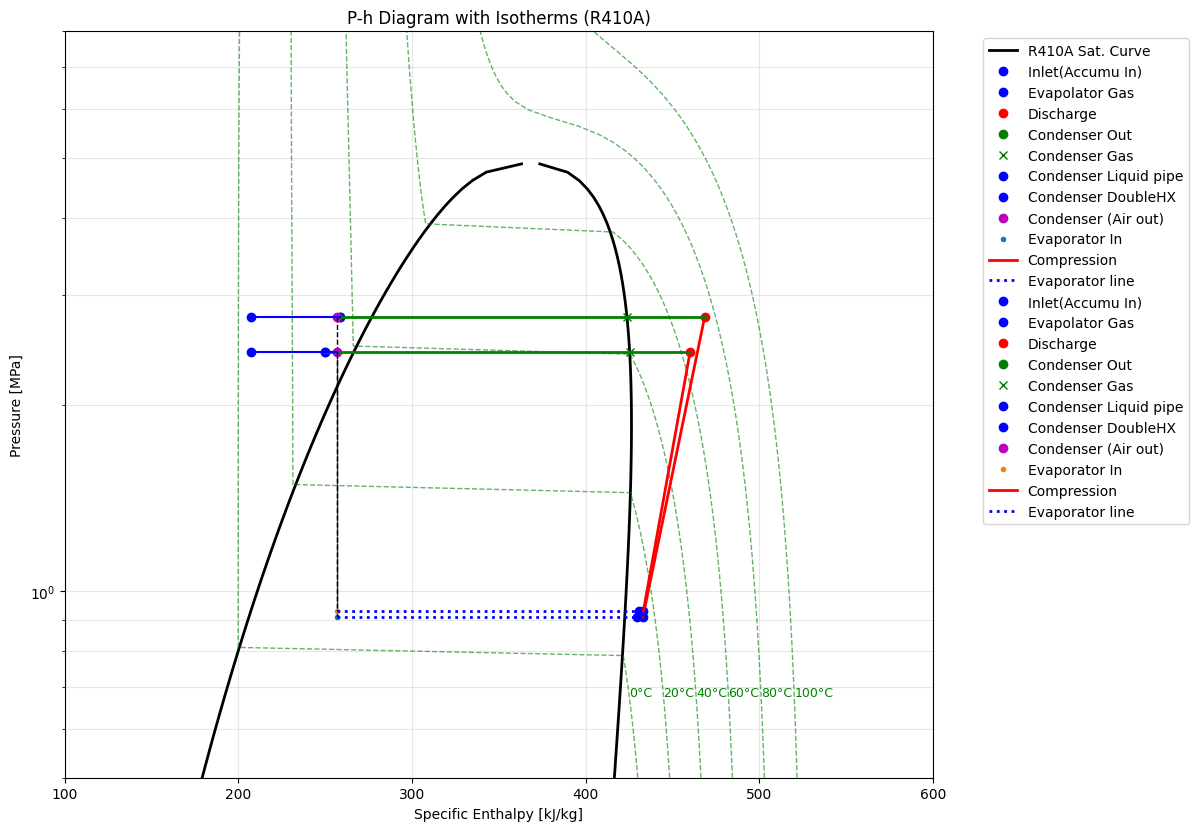

In [11]:


# --- 実行コード ---
plt.figure(figsize=(12, 8))

# R410A をプロット
plot_ph_diagram('R410A', 'black')

## 23:05
time_snapshot = '2023-08-20 23:35'
plot_refrigeration_cycle(
    T_evap_C = df.loc[time_snapshot]['teg'],
    T_cond_C = df.loc[time_snapshot]['tcg'],
    T_dis_C = df.loc[time_snapshot]['compressor_1_dischargetemp'],
    T_accum_in_C = df.loc[time_snapshot]['ts'], #アキュムレータ入口温度
    T_cond_out_C = df.loc[time_snapshot]['t_liquid'],      # 凝縮器出口
    T_airout_C = 35.0,        # 外気温（仮設定）
    T_liquidpipe_C = df.loc[time_snapshot]['t_liquid'],  # 液管温度(データがないので't_liquid'を入れる)
    T_doubleHX_C = df.loc[time_snapshot]['tsh'],      # 二重管
    T_indoor_gas_C = df.loc[time_snapshot]['indoor_gas'],
    fluid_name = "R410A"
)

print(time_snapshot,df.loc[time_snapshot]['compressor_1_dischargetemp'])
print(df.loc[time_snapshot])

time_snapshot = '2023-08-21 06:25'
plot_refrigeration_cycle(
    T_evap_C = df.loc[time_snapshot]['teg'],
    T_cond_C = df.loc[time_snapshot]['tcg'],
    T_dis_C = df.loc[time_snapshot]['compressor_1_dischargetemp'],
    T_accum_in_C = df.loc[time_snapshot]['ts'], #アキュムレータ入口温度
    T_cond_out_C = df.loc[time_snapshot]['t_liquid'],      # 凝縮器出口
    T_airout_C = 35.0,        # 外気温（仮設定）
    T_liquidpipe_C = df.loc[time_snapshot]['t_liquid'], # 液管温度(データがないので't_liquid'を入れる)
    T_doubleHX_C = df.loc[time_snapshot]['tsh'],      # 二重管
    T_indoor_gas_C = df.loc[time_snapshot]['indoor_gas'],
    fluid_name = "R410A"
)

print(time_snapshot,df.loc[time_snapshot]['compressor_1_dischargetemp'])
print(df.loc[time_snapshot])

plt.yscale('log')
plt.grid(True, which='both', ls='-', alpha=0.2)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# 仕上げ
plt.yscale('log')
plt.xlabel('Specific Enthalpy [kJ/kg]')
plt.ylabel('Pressure [MPa]')
plt.title('P-h Diagram with Isotherms (R410A)')
plt.grid(True, which="both", ls="-", alpha=0.3)

# 軸の範囲調整
plt.xlim(100, 600)
plt.ylim(0.5, 8)

plt.show()

# R410Aは非共沸冷媒なので注意が必要

```

CP.PropsSI('P', 'T', 16 + C_K_convert, 'Q', 0.5, fluid_name) 

```



```

---------------------------------------------------------------------------ValueError Traceback (most recent call last)Cell In[12], line 1----> 1 CP.PropsSI('P', 'T', 16 + C_K_convert, 'Q', 0.5, fluid_name) File CoolProp/CoolProp.pyx:491, in CoolProp.CoolProp.PropsSI()File CoolProp/CoolProp.pyx:571, in CoolProp.CoolProp.PropsSI()File CoolProp/CoolProp.pyx:458, in CoolProp.CoolProp.__Props_err2()ValueError: For pseudo-pure fluid, quality must be equal to 0 or 1. Two-phase quality is not defined : PropsSI("P","T",289.15,"Q",0.5,"R410A")

```

結論から言うと、エラーの理由は **「R410Aのような非共沸混合物（疑似純粋流体）に対して、温度（T）と乾き度（Q）を組み合わせて計算しようとしたから」** です。

エラーメッセージにある `For pseudo-pure fluid, quality must be equal to 0 or 1.` は、CoolPropの仕様上の制限を指しています。

---

## なぜこのエラーが出るのか？

R410Aなどは複数の冷媒が混ざった混合物ですが、CoolPropでは「疑似純粋流体（Pseudo-pure fluid）」として扱われます。これらの流体には**温度勾配（グライド）**が存在するため、気液二相領域（$0 < Q < 1$）において、温度と乾き度の関係が一意に決まりにくいという性質があります。

### CoolPropの制限事項

* **飽和状態（Q=0 または Q=1）:** 温度 $T$ から圧力を計算できます。
* **二相領域（0 < Q < 1）:** 疑似純粋流体の場合、**温度 $T$ と 乾き度 $Q$ の組み合わせによる計算がサポートされていません。**

---

## 解決策

このエラーを回避するには、入力パラメータの組み合わせを変更する必要があります。一般的には、**「圧力 (P) と 乾き度 (Q)」** を使うのが最も確実です。

### 1. 圧力から計算する場合（推奨）

もしその温度での飽和圧力を知りたい、あるいはその圧力下での二相状態を計算したい場合は、まず飽和圧力を求めてからそれを利用します。

```python
import CoolProp.CoolProp as CP

fluid_name = 'R410A'
T_K = 16 + 273.15

# 1. まずその温度における露点(Q=1)または沸点(Q=0)の圧力を取得する
P_sat = CP.PropsSI('P', 'T', T_K, 'Q', 1, fluid_name)

# 2. その圧力を使って、他の物性値を計算する（例：エンタルピーなど）
# PとQの組み合わせなら、二相領域でもエラーになりません
H = CP.PropsSI('H', 'P', P_sat, 'Q', 0.5, fluid_name)

```

### 2. 単に「特定の温度での飽和圧力」を知りたい場合

乾き度が $0.5$ であっても、飽和状態であれば圧力は（グライドを考慮した定義によりますが）一定の範囲にあります。単に圧力を知りたいだけなら、`Q=0` または `Q=1` を指定してください。

```python
# 沸点圧力を知りたい場合
P_bubble = CP.PropsSI('P', 'T', T_K, 'Q', 0, fluid_name)

# 露点圧力を知りたい場合
P_dew = CP.PropsSI('P', 'T', T_K, 'Q', 1, fluid_name)

```

---

## まとめ

* **原因:** R410Aに対して `T` と `Q=0.5` を同時に渡したこと。
* **対策:** `P` と `Q` の組み合わせで計算するか、`Q` を `0` か `1` に固定して圧力を求めてから次の計算に回す。

もし、特定の「圧力」が不明な状態で二相状態の物性を出したい場合は、どの変数が手元にあるか教えていただければ、最適なコードを提案します。

他に計算したい物性値（エンタルピーやエントロピーなど）はありますか？

結論から言うと、R410Aが**「非共沸混合物（ゼオトロピック混合物）」**であり、**温度勾配（温度グライド）**を持っているからです。

純粋な物質（水など）であれば、ある温度での飽和圧力は一つしかありません。しかし、R410Aのように複数の冷媒（R32とR125）を混ぜたものは、沸騰が始まる温度と、蒸発が完了する温度が異なります。

---

### なぜ値が異なるのか？

CoolPropで `Q=0` と `Q=1` を指定したとき、それぞれ以下の状態の圧力を計算しています。

1. **`Q=0`（飽和液 / 沸点）**: 液体が泡立ち始めるポイント（Bubble Point）
2. **`Q=1`（飽和蒸気 / 露点）**: 蒸気が結露し始めるポイント（Dew Point）

R410Aは混合物であるため、**「同じ温度（16℃）であっても、液体として存在できる圧力（沸点圧力）と、蒸気として存在できる圧力（露点圧力）がわずかに異なる」**という現象が起きます。これが「温度グライド」の圧力側への現れです。

### 実際の数値のイメージ

計算結果を見ると、おそらく `Q=0`（沸点）のときの方が、`Q=1`（露点）のときよりも圧力が**高く**出ているはずです。

* **`Q=0`**: 16℃で液体を維持するために必要な圧力
* **`Q=1`**: 16℃で蒸気を維持するために必要な圧力

---

### 使い分けのヒント

冷凍サイクルの計算などで「16℃の蒸発温度」と言いたい場合、どちらの圧力を使うべきかは設計指針によります：

* **凝縮器の計算**: 一般に露点（`Q=1`）や平均温度が使われます。
* **蒸発器の計算**: 入口と出口の平均（Mid-point）や、露点（`Q=1`）が基準にされることが多いです。

もし、システムの「基準となる圧力」を一つ決めたいのであれば、計算の目的に合わせて `Q=0` か `Q=1` かを統一する必要があります。

この二つの圧力の平均値（中間的な圧力）を使って計算を進めたいですか？それとも、特定の機器（蒸発器など）の設計用ですか？

In [16]:
print(CP.PropsSI('P', 'T', 16 + C_K_convert, 'Q', 1.0, fluid_name) )
print(CP.PropsSI('P', 'T', 16 + C_K_convert, 'Q', 0, fluid_name) )

1290439.8360795758
1294524.7255227584


In [ ]:
time_snapshot = '2023-08-20 23:35'
df.loc[time_snapshot]['tcg']

tcg                                45.535156
t_liquid                           36.000000
rpm                               138.000000
teg                                 4.113281
ts                                 13.500000
tsh                                 5.000000
compressor_1_dischargetemp         75.000000
refrigerantpipe_1_highpressure      2.655673
compressor_coolingfin_temp         57.000000
compressor_surface_temp            70.000000
outdoor_deicer_temp                45.000000
stopvalve_liquid_temp              14.699219
subcool_mov_flowratio              50.500000
indoor_liquid                       7.875000
indoor_gas                         10.562500
indoor_ev_pulse                   498.000000
Name: 2023-08-20 23:35:00, dtype: float64